### Utils & imports

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from sklearn.decomposition import FastICA
import warnings
from picard import picard
SEED = 69

In [11]:
# Импорт необходимых библиотек (предполагается, что numpy и scipy.signal уже импортированы)
def generate_eeg(sfreq=250, duration=10, n_channels=8, n_sources=None, seed=None,
                 # Параметры контроля компонентов
                 add_delta=True, add_theta=True, add_alpha=True, 
                 add_beta=True, add_gamma=True,
                 
                 # Частотные диапазоны (в Гц)
                 delta_range=(0.5, 4),
                 theta_range=(4, 8),
                 alpha_range=(8, 13),
                 beta_range=(13, 30),
                 gamma_range=(30, 45),
                 
                 # Базовые амплитуды для каждого ритма (мкВ)
                 delta_amp_base=25,
                 theta_amp_base=20,
                 alpha_amp_base=15,
                 beta_amp_base=8,
                 gamma_amp_base=5,
                 
                 # Параметры нестационарности (коэффициенты вариации амплитуды)
                 delta_cv=0.3,
                 theta_cv=0.4,
                 alpha_cv=0.5,
                 beta_cv=0.6,
                 gamma_cv=0.7,
                 
                 # Параметры шума
                 phys_noise_amp=3.0,
                 phys_noise_color=0.5,  # 0 = белый шум, 1 = красный шум
                 slow_drift_amp=2.0,
                 slow_drift_freq=0.1,
                 
                 # Пространственная структура
                 channel_positions=None,  # [(x, y, z), ...] or [(x, y), ...]
                 source_positions=None,   # [(x, y, z), ...] для генераторов сигналов
                 spatial_attenuation=2.0, # Затухание с расстоянием
                 
                 # Дополнительные параметры
                 nonlinearity_factor=0.1,  # Коэффициент нелинейных искажений
                 amplitude_variability=0.2, # Общая вариабельность амплитуд между каналами
                 verbose=True):
    """
    Генерирует реалистичный синтетический ЭЭГ-сигнал с настраиваемыми параметрами.
    
    Параметры
    ----------
    sfreq : float
        Частота дискретизации в Гц
    duration : float
        Длительность сигнала в секундах
    n_channels : int
        Количество каналов (электродов)
    n_sources : int, optional
        Количество независимых источников сигнала. По умолчанию max(3, n_channels//2)
        
    add_delta, add_theta, add_alpha, add_beta, add_gamma : bool
        Включение/выключение соответствующих частотных диапазонов
    
    delta_range, theta_range, alpha_range, beta_range, gamma_range : tuple
        Частотные диапазоны для каждого ритма в Гц
    
    delta_amp_base, theta_amp_base, alpha_amp_base, beta_amp_base, gamma_amp_base : float
        Базовые амплитуды для каждого ритма в микровольтах
    
    delta_cv, theta_cv, alpha_cv, beta_cv, gamma_cv : float
        Коэффициенты вариации для нестационарности амплитуд (0 = постоянная амплитуда)
    
    phys_noise_amp : float
        Амплитуда физиологического шума
    phys_noise_color : float
        Цвет шума: 0 = белый шум, 1 = красный шум (1/f)
    slow_drift_amp : float
        Амплитуда медленного дрейфа
    slow_drift_freq : float
        Частота медленного дрейфа в Гц
    
    channel_positions : array-like, optional
        Координаты электродов. Если None, генерируются равномерно по окружности
    source_positions : array-like, optional
        Координаты источников сигнала. Если None, генерируются случайно в пределах сферы
    spatial_attenuation : float
        Показатель затухания сигнала с расстоянием
    
    nonlinearity_factor : float
        Степень нелинейных искажений (0 = линейный сигнал)
    amplitude_variability : float
        Вариабельность амплитуд между каналами
    verbose : bool
        Выводить ли информационные сообщения
    
    Возвращает
    ----------
    times : ndarray
        Массив временных меток
    eeg : ndarray
        Сгенерированный ЭЭГ-сигнал в формате [каналы, отсчеты]
    source_activities : dict
        Информация об активности источников (для отладки и анализа)
    """
    # Если количество источников не задано, устанавливаем значение по умолчанию: 
    # максимум из 3 или половины количества каналов (округленное вниз)
    if n_sources is None:
        n_sources = max(3, n_channels // 2)
    
    # Инициализация генератора случайных чисел с заданным seed для воспроизводимости результатов
    rng = np.random.default_rng(seed)
    
    # Генерация временных меток от 0 до duration с шагом 1/sfreq (частота дискретизации)
    times = np.arange(0, duration, 1/sfreq)
    # Вычисление общего количества отсчетов сигнала
    n_samples = len(times)
    
    # Если координаты электродов не заданы, генерируем их расположение по окружности
    if channel_positions is None:
        # Создание равномерно распределенных углов по окружности для n_channels электродов
        angles = np.linspace(0, 2*np.pi, n_channels, endpoint=False)
        # Расчет координат (x, y) на единичной окружности с использованием тригонометрических функций
        channel_positions = np.column_stack([np.cos(angles), np.sin(angles)])
    
    # Если координаты источников не заданы, генерируем случайные позиции внутри круга
    if source_positions is None:
        # Генерация случайных координат в диапазоне [-0.7, 0.7] для 2D-пространства
        source_positions = rng.uniform(-0.7, 0.7, size=(n_sources, 2)) 
    
    # Инициализация основного массива ЭЭГ нулями: матрица [количество каналов × количество отсчетов]
    eeg = np.zeros((n_channels, n_samples))
    # Инициализация словаря для хранения активности каждого типа ритма по источникам
    source_activities = {
        'delta': np.zeros((n_sources, n_samples)),  # Дельта-ритмы для всех источников
        'theta': np.zeros((n_sources, n_samples)),  # Тета-ритмы
        'alpha': np.zeros((n_sources, n_samples)),  # Альфа-ритмы
        'beta': np.zeros((n_sources, n_samples)),   # Бета-ритмы
        'gamma': np.zeros((n_sources, n_samples)),  # Гамма-ритмы
        'noise': np.zeros((n_sources, n_samples))   # Шумовые компоненты
    }
    
    # Генерация активности для каждого источника сигнала
    for source_idx in range(n_sources):
        # Выбор случайной базовой частоты для дельта-ритма в заданном диапазоне
        delta_freq = rng.uniform(*delta_range)
        # Выбор случайной базовой частоты для тета-ритма в заданном диапазоне
        theta_freq = rng.uniform(*theta_range)
        # Выбор случайной базовой частоты для альфа-ритма в заданном диапазоне
        alpha_freq = rng.uniform(*alpha_range)
        # Выбор случайной базовой частоты для бета-ритма в заданном диапазоне
        beta_freq = rng.uniform(*beta_range)
        # Выбор случайной базовой частоты для гамма-ритма в заданном диапазоне
        gamma_freq = rng.uniform(*gamma_range)
        
        # Внутренняя функция для генерации нестационарной амплитуды (плавно меняющейся во времени)
        def generate_nonstationary_amplitude(base_amp, cv, n_samples):
            # Если коэффициент вариации <= 0, возвращаем постоянную амплитуду
            if cv <= 0:
                return np.ones(n_samples) * base_amp
            # Генерация случайных отклонений амплитуды с нормальным распределением
            amp_var = base_amp * cv * rng.standard_normal(n_samples)
            # Настройка низкочастотного фильтра Баттерворта 2-го порядка для сглаживания
            b, a = signal.butter(2, 0.1, fs=sfreq)  # 0.1 = частота среза в долях от sfreq
            # Применение двусторонней фильтрации для удаления фазовых искажений
            amp_var = signal.filtfilt(b, a, amp_var)
            # Возврат базовой амплитуды с наложенной сглаженной вариацией
            return base_amp + amp_var
        
        # Генерация дельта-ритма с нестационарной амплитудой, если он включен
        if add_delta:
            # Получение амплитуды с вариациями
            delta_amp = generate_nonstationary_amplitude(delta_amp_base, delta_cv, n_samples)
            # Генерация синусоидального сигнала с плавно меняющейся амплитудой
            source_activities['delta'][source_idx] = delta_amp * np.sin(2 * np.pi * delta_freq * times)
        
        # Генерация тета-ритма (аналогично дельта) с фазовым сдвигом π/6 для разнообразия
        if add_theta:
            theta_amp = generate_nonstationary_amplitude(theta_amp_base, theta_cv, n_samples)
            source_activities['theta'][source_idx] = theta_amp * np.sin(2 * np.pi * theta_freq * times + np.pi/6)
        
        # Генерация альфа-ритма с фазовым сдвигом π/4
        if add_alpha:
            alpha_amp = generate_nonstationary_amplitude(alpha_amp_base, alpha_cv, n_samples)
            source_activities['alpha'][source_idx] = alpha_amp * np.sin(2 * np.pi * alpha_freq * times + np.pi/4)
        
        # Генерация бета-ритма с фазовым сдвигом π/3
        if add_beta:
            beta_amp = generate_nonstationary_amplitude(beta_amp_base, beta_cv, n_samples)
            source_activities['beta'][source_idx] = beta_amp * np.sin(2 * np.pi * beta_freq * times + np.pi/3)
        
        # Генерация гамма-ритма с фазовым сдвигом π/12
        if add_gamma:
            gamma_amp = generate_nonstationary_amplitude(gamma_amp_base, gamma_cv, n_samples)
            source_activities['gamma'][source_idx] = gamma_amp * np.sin(2 * np.pi * gamma_freq * times + np.pi/12)
        
        # Генерация физиологического шума для источника
        noise = rng.standard_normal(n_samples)  # Сначала белый шум
        # Если требуется цветной шум (не белый)
        if phys_noise_color > 0:
            # Получение частот для спектрального анализа (только положительные частоты)
            freqs = np.fft.rfftfreq(n_samples, 1/sfreq)
            # Быстрое преобразование Фурье для перехода в частотную область
            spectral = np.fft.rfft(noise)
            
            # Создание весов для формирования 1/f спектра: высокие частоты подавляются
            weights = np.ones_like(freqs)
            # Для всех частот кроме нулевой (постоянной составляющей) применяем закон 1/f^color
            weights[1:] = 1 / (freqs[1:] ** phys_noise_color)  # freqs[1:] > 0 гарантированно
            
            # Нормализация весов для сохранения общей энергии сигнала
            weights = weights / np.linalg.norm(weights)
            # Применение весов к спектру
            spectral = spectral * weights
            
            # Обратное преобразование Фурье для возврата во временную область
            noise = np.fft.irfft(spectral, n=n_samples)
            
            # Масштабирование шума до заданной амплитуды
            noise = noise * (phys_noise_amp / (np.std(noise) + 1e-12))  # +1e-12 для защиты от деления на ноль
        else:
            # Для белого шума простое масштабирование
            noise = noise * phys_noise_amp
        
        # Сохранение сгенерированного шума в структуре данных
        source_activities['noise'][source_idx] = noise
    
    # Генерация медленного дрейфа (низкочастотной составляющей) как синусоиды
    slow_drift = slow_drift_amp * np.sin(2 * np.pi * slow_drift_freq * times)
    # Вычисление расстояний между каждым электродом и каждым источником
    # Используется векторизованная операция для эффективности:
    # 1. Расширение размерности массивов для broadcast-операции
    # 2. Вычитание координат источников из координат электродов
    # 3. Вычисление евклидова расстояния по осям x и y
    distances = np.linalg.norm(
        channel_positions[:, np.newaxis, :] - source_positions[np.newaxis, :, :],
        axis=2
    )
    
    # Нормализация расстояний относительно максимального расстояния в системе
    max_dist = np.max(distances)
    # Расчет весов по закону обратных квадратов с учетом параметра затухания
    weights = 1 / (1 + (distances / max_dist) ** spatial_attenuation)
    # Нормализация весов для каждого канала: сумма весов по источникам равна 1
    weights = weights / np.sum(weights, axis=1, keepdims=True)  # keepdims сохраняет размерность
    
    # Формирование сигнала для каждого канала ЭЭГ
    for ch_idx in range(n_channels):
        # Инициализация временного сигнала для текущего канала нулями
        channel_signal = np.zeros(n_samples)
        
        # Суммирование вкладов всех источников с учетом пространственных весов
        for source_idx in range(n_sources):
            # Получение веса для текущего источника и канала
            weight = weights[ch_idx, source_idx]
            # Инициализация сигнала источника
            source_signal = np.zeros(n_samples)
            
            # Добавление дельта-компонента, если включен
            if add_delta:
                source_signal += source_activities['delta'][source_idx]
            # Добавление тета-компонента
            if add_theta:
                source_signal += source_activities['theta'][source_idx]
            # Добавление альфа-компонента
            if add_alpha:
                source_signal += source_activities['alpha'][source_idx]
            # Добавление бета-компонента
            if add_beta:
                source_signal += source_activities['beta'][source_idx]
            # Добавление гамма-компонента
            if add_gamma:
                source_signal += source_activities['gamma'][source_idx]
            
            # Добавление шума источника
            source_signal += source_activities['noise'][source_idx]
            # Взвешенное суммирование вклада источника в канал
            channel_signal += weight * source_signal
        
        # Добавление медленного дрейфа с индивидуальной амплитудой для канала
        drift_amp = slow_drift_amp * (1 + amplitude_variability * rng.uniform(-0.5, 0.5))
        channel_signal += drift_amp * slow_drift
        
        # Добавление нелинейных искажений через гиперболический тангенс для реалистичности
        if nonlinearity_factor > 0:
            channel_signal = channel_signal + nonlinearity_factor * np.tanh(channel_signal)
        
        # Применение общей вариабельности амплитуды канала (случайное масштабирование)
        amp_factor = 1 + amplitude_variability * rng.uniform(-0.5, 0.5)
        eeg[ch_idx] = channel_signal * amp_factor
    
    # Проверка на наличие некорректных значений (NaN/Inf) в сигнале
    if np.isnan(eeg).any() or np.isinf(eeg).any():
        # Замена всех некорректных значений на нули
        eeg = np.nan_to_num(eeg, nan=0.0, posinf=0.0, neginf=0.0)
        # Вывод предупреждения при включенном verbose-режиме
        if verbose:
            print("Предупреждение: в сигнале обнаружены NaN/inf. Значения заменены на 0.")
    
    # Вывод информационного сообщения при включенном verbose-режиме
    if verbose:
        print(f"Сгенерирован ЭЭГ-сигнал: {n_channels} каналов, {duration} секунд, {sfreq} Гц")
        print(f"Источники: {n_sources}, включены ритмы: ", end="")
        rhythms = []
        if add_delta: rhythms.append("дельта")
        if add_theta: rhythms.append("тета")
        if add_alpha: rhythms.append("альфа")
        if add_beta: rhythms.append("бета")
        if add_gamma: rhythms.append("гамма")
        print(", ".join(rhythms))

    # Нормализация сигнала: приведение к диапазону ±50 мкВ для соответствия реальным ЭЭГ
    eeg = eeg / np.max(np.abs(eeg) + 1e-12) * 50  # +1e-12 для защиты от деления на ноль
    
    # Возврат результатов: временные метки, матрица ЭЭГ, данные об источниках
    return times, eeg, source_activities

In [12]:
import numpy as np
from scipy import signal
import warnings

def add_artifacts(times, eeg_clean, sfreq, *,
                  # Параметры управления типами артефактов
                  add_blinks=True,
                  add_muscle=True,
                  add_powerline=True,
                  
                  # Параметры моргания
                  blink_times=None,
                  blink_duration=0.4,
                  blink_sigma=0.15,
                  blink_amp=80,
                  blink_channels=None,
                  blink_weights=None,
                  
                  # Параметры мышечного шума
                  muscle_intervals=None,
                  muscle_amp=25,
                  muscle_channels=None,
                  muscle_weights=None,
                  muscle_freq_range=(20, 150),  # Частотный диапазон в Гц
                  muscle_bandpass=True,
                  
                  # Параметры сетевой помехи
                  powerline_amp=12,
                  powerline_freq=50,
                  powerline_phase=np.pi/4,
                  powerline_channels=None,
                  powerline_weights=None,
                  powerline_harmonics=None,  # Список (частота, амплитуда)
                  
                  # Общие параметры
                  seed=None,
                  verbose=True,
                  return_artifact_info=False):
    """
    Гибкое добавление артефактов в ЭЭГ-сигнал с детальной настройкой параметров.
    
    Параметры
    ----------
    times : array-like
        Временные метки для каждого отсчёта
    eeg_clean : ndarray
        Исходный ЭЭГ-сигнал в формате [каналы, отсчёты]
    sfreq : float
        Частота дискретизации в Гц
    
    add_blinks, add_muscle, add_powerline : bool
        Флаги включения/выключения соответствующих типов артефактов
    
    blink_times : list, optional
        Список времён появления морганий в секундах. По умолчанию [1.5, 4.2, 7.8]
    blink_duration : float
        Длительность одного моргания в секундах
    blink_sigma : float
        Параметр формы гауссоподобного моргания
    blink_amp : float
        Амплитуда моргания в микровольтах
    blink_channels : list, optional
        Индексы каналов для добавления моргания. По умолчанию [0, 1]
    blink_weights : list, optional
        Относительные веса для каналов моргания. По умолчанию [1.0, 0.8]
    
    muscle_intervals : list of tuples, optional
        Список временных интервалов [(начало, конец), ...] в секундах.
        По умолчанию [(2.5, 5.5)]
    muscle_amp : float
        Базовая амплитуда мышечного шума
    muscle_channels : list, optional
        Индексы каналов для мышечного шума. По умолчанию [2, 3]
    muscle_weights : list, optional
        Относительные веса для каналов мышечного шума. По умолчанию [1.0, 0.6]
    muscle_freq_range : tuple
        Частотный диапазон мышечного шума в Гц
    muscle_bandpass : bool
        Применять ли полосовую фильтрацию к мышечному шуму
    
    powerline_amp : float
        Амплитуда основной сетевой помехи
    powerline_freq : float
        Частота сетевой помехи в Гц
    powerline_phase : float
        Начальная фаза сетевой помехи
    powerline_channels : list, optional
        Индексы каналов для сетевой помехи. По умолчанию [4, 5]
    powerline_weights : list, optional
        Относительные веса для каналов сетевой помехи. По умолчанию [1.0, 0.9]
    powerline_harmonics : list of tuples, optional
        Список гармоник [(частота, относительная_амплитуда), ...]
    
    seed : int, optional
        Зерно для генератора случайных чисел
    verbose : bool
        Выводить ли информационные сообщения
    return_artifact_info : bool
        Возвращать ли детальную информацию об артефактах
    
    Возвращает
    ----------
    eeg_with_artifacts : ndarray
        Копия ЭЭГ с добавленными артефактами
    artifact_info : dict, optional
        Информация о добавленных артефактах (если return_artifact_info=True)
    """
    # Создание локального генератора случайных чисел с заданным seed для воспроизводимости экспериментов
    rng = np.random.default_rng(seed)
    
    # Создание полной копии исходного сигнала для избежания модификации оригинальных данных
    eeg_with_artifacts = eeg_clean.copy()
    # Определение количества каналов (электродов) и временных отсчетов в сигнале
    n_channels, n_samples = eeg_with_artifacts.shape
    
    # Инициализация структуры для хранения детальной информации о добавленных артефактах
    artifact_info = {
        'blinks': [],                  # Информация о морганиях
        'muscle_artifacts': [],        # Информация о мышечных артефактах
        'powerline_artifacts': []      # Информация о сетевых помехах
    }
    
    # === ДОБАВЛЕНИЕ МОРГАНИЙ ===
    # Проверка флага включения морганий
    if add_blinks:
        # Установка стандартных временных точек для морганий, если пользователь не указал свои
        if blink_times is None:
            blink_times = [1.5, 4.2, 7.8]
        
        # Выбор каналов для морганий: по умолчанию первые два канала (лобные электроды)
        if blink_channels is None:
            blink_channels = [0, 1] if n_channels > 1 else [0]
        
        # Установка относительной силы влияния моргания на разные каналы
        if blink_weights is None:
            # Для двух каналов: полная амплитуда на первом, ослабленная на втором
            blink_weights = [1.0, 0.8] if n_channels > 1 else [1.0]
            # Обрезка списка весов до количества указанных каналов
            blink_weights = blink_weights[:len(blink_channels)]
        
        # Обработка каждого моргания из списка
        for blink_time in blink_times:
            # Расчет временных границ моргания (центр + длительность/2)
            start_time = blink_time - blink_duration/2
            end_time = blink_time + blink_duration/2
            
            # Проверка, что моргание полностью помещается в запись
            if start_time < 0 or end_time > times[-1]:
                if verbose:
                    print(f"Предупреждение: моргание в момент {blink_time:.2f} с выходит за границы записи")
                continue
            
            # Генерация временной шкалы для формы моргания
            t_blink = np.linspace(-blink_duration/2, blink_duration/2, int(blink_duration * sfreq))
            # Создание биологически правдоподобной формы моргания (комбинация двух гауссиан)
            blink_wave = blink_amp * (np.exp(-(t_blink/(blink_sigma*1.5))**2) - 0.6 * np.exp(-(t_blink/(blink_sigma*0.7))**2))
            
            # Расчет индексов начала и конца моргания в массиве данных
            start_idx = int(start_time * sfreq)
            end_idx = start_idx + len(blink_wave)
            
            # Добавление моргания в выбранные каналы с учетом весов
            for ch_idx, weight in zip(blink_channels, blink_weights):
                # Проверка корректности номера канала
                if 0 <= ch_idx < n_channels:
                    eeg_with_artifacts[ch_idx, start_idx:end_idx] += blink_wave * weight
            
            # Сохранение информации о добавленном моргании для отчетности
            artifact_info['blinks'].append({
                'time': blink_time,
                'duration': blink_duration,
                'channels': blink_channels,
                'weights': blink_weights,
                'amplitude': blink_amp
            })
        
        # Вывод отчета о количестве добавленных морганий
        if verbose and artifact_info['blinks']:
            print(f"Добавлено {len(artifact_info['blinks'])} морганий")
    
    # === ДОБАВЛЕНИЕ МЫШЕЧНОГО ШУМА ===
    # Проверка флага включения мышечных артефактов
    if add_muscle:
        # Установка стандартных временных интервалов для мышечной активности
        if muscle_intervals is None:
            muscle_intervals = [(2.5, 5.5)]
        
        # Выбор каналов размещения мышечных артефактов (височные/теменные области)
        if muscle_channels is None:
            muscle_channels = [2, 3] if n_channels > 3 else list(range(2, min(4, n_channels)))
            # Защита от пустого списка каналов
            if not muscle_channels:
                muscle_channels = [0]  # Резервный вариант - первый канал
        
        # Установка относительной интенсивности артефактов для разных каналов
        if muscle_weights is None:
            base_weights = [1.0, 0.6, 0.4, 0.3]  # Стандартные веса для до 4 каналов
            muscle_weights = base_weights[:len(muscle_channels)]
        
        # Обработка каждого временного интервала с мышечной активностью
        for interval_start, interval_end in muscle_intervals:
            # Расчет индексов начала и конца интервала в массиве
            start_idx = max(0, int(interval_start * sfreq))
            end_idx = min(n_samples, int(interval_end * sfreq))
            
            # Пропуск некорректных интервалов
            if end_idx <= start_idx:
                continue
            
            # Длительность интервала в отсчетах
            duration = end_idx - start_idx
            
            # Генерация белого шума с заданной амплитудой
            muscle_noise = muscle_amp * rng.standard_normal(duration)
            
            # Применение полосовой фильтрации для имитации реальных мышечных артефактов
            if muscle_bandpass and muscle_freq_range:
                # Расчет граничных частот с учетом теоремы Найквиста
                nyquist = sfreq / 2
                low_freq = max(1, min(muscle_freq_range[0], nyquist * 0.95))
                high_freq = min(nyquist * 0.95, muscle_freq_range[1])
                
                # Проверка корректности частотного диапазона
                if low_freq < high_freq:
                    # Создание полосового фильтра Баттерворта 4-го порядка
                    b, a = signal.butter(4, [low_freq, high_freq], btype='band', fs=sfreq)
                    # Применение фильтра без фазовых искажений
                    muscle_noise = signal.filtfilt(b, a, muscle_noise)
                else:
                    # Предупреждение о некорректных параметрах фильтрации
                    warnings.warn(f"Некорректный диапазон частот для мышечного шума: {muscle_freq_range}. Фильтрация отключена.")
                    muscle_bandpass = False
            
            # Добавление отфильтрованного шума в выбранные каналы
            for ch_idx, weight in zip(muscle_channels, muscle_weights):
                if 0 <= ch_idx < n_channels:
                    eeg_with_artifacts[ch_idx, start_idx:end_idx] += muscle_noise * weight
            
            # Сохранение информации об артефакте для отчетности
            artifact_info['muscle_artifacts'].append({
                'interval': (interval_start, interval_end),
                'channels': muscle_channels,
                'weights': muscle_weights,
                'amplitude': muscle_amp,
                'filtered': muscle_bandpass
            })
        
        # Вывод отчета о добавленных мышечных артефактах
        if verbose and artifact_info['muscle_artifacts']:
            print(f"Добавлен мышечный шум в {len(muscle_intervals)} интервалах")
    
    # === ДОБАВЛЕНИЕ СЕТЕВОЙ ПОМЕХИ ===
    # Проверка флага включения сетевой помехи
    if add_powerline:
        # Выбор каналов для помехи (теменные/затылочные области)
        if powerline_channels is None:
            powerline_channels = [4, 5] if n_channels > 5 else list(range(4, min(6, n_channels)))
            # Защита от пустого списка
            if not powerline_channels:
                powerline_channels = list(range(min(2, n_channels)))  # Резервные каналы
        
        # Установка относительной интенсивности помехи для разных каналов
        if powerline_weights is None:
            base_weights = [1.0, 0.9, 0.8, 0.7]  # Стандартные веса
            powerline_weights = base_weights[:len(powerline_channels)]
        
        # Расчет фазового сдвига относительно начала записи
        phase_shift = 2 * np.pi * powerline_freq * times[0]
        # Генерация основной синусоидальной помехи сети
        powerline = powerline_amp * np.sin(2 * np.pi * powerline_freq * times + powerline_phase + phase_shift)
        
        # Добавление гармоник (кратных частот) для реалистичности
        if powerline_harmonics:
            for harmonic_freq, harmonic_amp in powerline_harmonics:
                # Расчет порядка гармоники относительно основной частоты
                k = harmonic_freq / powerline_freq
                # Генерация гармонической составляющей с сохранением фазовых соотношений
                harmonic = harmonic_amp * powerline_amp * np.sin(
                    2 * np.pi * harmonic_freq * times + k * powerline_phase
                )
                powerline += harmonic
        
        # Наложение помехи на выбранные каналы
        for ch_idx, weight in zip(powerline_channels, powerline_weights):
            if 0 <= ch_idx < n_channels:
                eeg_with_artifacts[ch_idx, :] += powerline * weight
        
        # Сохранение информации о сетевой помехе
        artifact_info['powerline_artifacts'].append({
            'frequency': powerline_freq,
            'amplitude': powerline_amp,
            'phase': powerline_phase,
            'channels': powerline_channels,
            'weights': powerline_weights,
            'harmonics': powerline_harmonics if powerline_harmonics else []
        })
        
        # Вывод отчета о добавлении сетевой помехи
        if verbose:
            print(f"Добавлена сетевая помеха ({powerline_freq} Гц) в {len(powerline_channels)} каналов")
    
    # Финальное сообщение об успешном выполнении
    if verbose:
        print("Артефакты успешно добавлены")
    
    # Возврат результата в зависимости от требований пользователя
    if return_artifact_info:
        return eeg_with_artifacts, artifact_info
    return eeg_with_artifacts

## new version

In [13]:
import numpy as np
import mne
from mne.preprocessing import ICA
from scipy import stats  

# Глобальная константа для воспроизводимости результатов (должна быть определена ранее)
SEED = 42

def apply_ica_to_eeg(eeg_data, sfreq, n_components=None, method='picard', 
                     random_state=SEED, exclude_components=None, 
                     visualize=False, verbose=True):
    """
    Применяет метод независимых компонент (ICA) для удаления артефактов из ЭЭГ-данных.
    
    Параметры:
    eeg_data : ndarray
        Данные ЭЭГ в формате [каналы, отсчеты]
    sfreq : float
        Частота дискретизации в Гц
    n_components : int, optional
        Количество компонентов ICA. По умолчанию min(каналы-1, 20)
    method : str
        Метод расчета ICA ('picard', 'fastica', 'infomax')
    random_state : int
        Фиксированное состояние для генератора случайных чисел
    exclude_components : list, optional
        Ручное указание компонентов для удаления
    visualize : bool
        Показывать графики компонентов
    verbose : bool
        Выводить отладочную информацию
    
    Возвращает:
    cleaned_data : ndarray
        Очищенные данные ЭЭГ
    ica : объект ICA
        Обученная модель ICA
    excluded_idx : list
        Индексы удаленных компонентов
    """
    
    # Получение количества каналов и временных отсчетов из входных данных
    n_channels, n_samples = eeg_data.shape
    
    # 1. НАСТРОЙКА КАНАЛОВ И МОНТАЖА
    # Стандартные имена электродов для системы 10-20 (лобные, центральные, теменные, затылочные)
    standard_montage_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8']
    
    # Автоматическое формирование имен каналов:
    # Если каналов меньше стандартных - берем соответствующее количество имен
    # Если больше - генерируем имена EEG_0, EEG_1 и т.д.
    ch_names = standard_montage_names[:n_channels] if n_channels <= len(standard_montage_names) else [f'EEG_{i}' for i in range(n_channels)]
    
    # Создание информационного объекта MNE с параметрами записи
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    
    # Преобразование сырых данных в формат RawArray MNE
    raw = mne.io.RawArray(eeg_data, info, verbose=False)
    
    try:
        # Попытка установить стандартную схему расположения электродов (10-20 система)
        raw.set_montage(mne.channels.make_standard_montage('standard_1020'))
    except:
        # Если стандартный монтаж не применим (нестандартное количество каналов), пропускаем шаг
        pass

    # 2. ПРЕДВАРИТЕЛЬНАЯ ФИЛЬТРАЦИЯ
    # Создание копии данных для ICA с обязательной high-pass фильтрацией 1 Гц
    # Это критически важно для корректной работы алгоритма ICA
    raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None, verbose=False)
    
    # Автоматический расчет количества компонентов ICA, если не задано вручную
    if n_components is None:
        n_components = min(n_channels - 1, 20)  # Ограничение сверху 20 компонентами
    
    # 3. ИНИЦИАЛИЗАЦИЯ И ОБУЧЕНИЕ ICA
    # Создание объекта ICA с параметрами:
    # - n_components: количество извлекаемых компонент
    # - method: алгоритм расчета (PICARD обеспечивает высокую точность)
    # - fit_params: параметры сходимости (ортогональность и расширенный режим)
    # - random_state: воспроизводимость результатов
    # - max_iter: максимальное количество итераций обучения
    ica = ICA(n_components=n_components, method=method, fit_params=dict(ortho=True, extended=True),
              random_state=random_state, max_iter=1000, verbose=False)
    
    # Обучение модели ICA на предварительно отфильтрованных данных
    ica.fit(raw_for_ica, verbose=False)
    
    # 4. АВТОМАТИЧЕСКАЯ ДЕТЕКЦИЯ АРТЕФАКТОВ
    # Если компоненты для удаления не заданы вручную, выполняем автоматическое определение
    if exclude_components is None:
        # Получение временных рядов всех независимых компонент
        sources = ica.get_sources(raw_for_ica).get_data()
        
        # Расчет спектральной плотности мощности (PSD) для каждого компонента
        psd, freqs = mne.time_frequency.psd_array_welch(
            sources, 
            sfreq=sfreq, 
            fmin=1, 
            fmax=100,           # Анализ до 100 Гц
            n_fft=sfreq*2,      # Длина FFT для хорошего частотного разрешения
            verbose=False
        )
        
        # --- А. ДЕТЕКЦИЯ СЕТЕВОЙ ПОМЕХИ (50 Гц) ---
        # Поиск индекса для частоты 50 Гц в массиве частот
        idx_50 = np.argmin(np.abs(freqs - 50))
        # Индексы соседних частот (45-48 Гц и 52-55 Гц) для оценки фонового уровня
        idx_neighbors = np.where(((freqs >= 45) & (freqs <= 48)) | ((freqs >= 52) & (freqs <= 55)))[0]
        powerline_artifacts = []  # Список компонентов с сетевой помехой
        
        # Анализ каждого компонента на наличие характерного пика 50 Гц
        for i in range(n_components):
            power_50 = psd[i, idx_50]  # Мощность на 50 Гц
            # Средняя мощность в соседних диапазонах (фон)
            power_neighbors = np.mean(psd[i, idx_neighbors]) + 1e-12  # +1e-12 для защиты от деления на ноль
            
            # Если пик на 50 Гц в 3 раза превышает фон - помечаем компонент
            if power_50 > 3 * power_neighbors: 
                powerline_artifacts.append(i)

        # --- Б. ДЕТЕКЦИЯ МОРГАНИЙ (через лобные каналы Fp1/Fp2) ---
        blink_artifacts = []  # Список компонентов с морганиями
        
        # Проверка наличия достаточного количества каналов для анализа
        if n_channels >= 2:
            # Извлечение данных из первых двух каналов (предположительно Fp1 и Fp2)
            frontal_data = raw.get_data()[[0, 1]]
            
            # Анализ каждого компонента
            for i in range(n_components):
                # Расчет корреляции компонента с лобными каналами
                corrs = [np.corrcoef(sources[i], ch_data)[0, 1] for ch_data in frontal_data]
                max_corr = np.max(np.abs(corrs))  # Максимальная корреляция по модулю
                
                # Расчет куртозиса (меры "пиковости") временного ряда компонента
                kurt = stats.kurtosis(sources[i], fisher=True)  # fisher=True означает нормализацию
                
                # Отладочная информация при включенном verbose-режиме
                if verbose:
                    print(f"Компонент {i}: Макс.корреляция={max_corr:.2f}, Куртозис={kurt:.2f}", end="")
                
                # Логика классификации:
                # - Высокая корреляция (>0.6) ИЛИ
                # - Средняя корреляция (>0.4) + высокий куртозис (>1.5)
                if (max_corr > 0.6) or (max_corr > 0.4 and kurt > 1.5):
                    blink_artifacts.append(i)
                    if verbose: 
                        print(" -> ОПРЕДЕЛЕНО КАК МОРГАНИЕ!")
                else:
                    if verbose: 
                        print("")  # Перенос строки для отладки

        # --- В. ДЕТЕКЦИЯ МЫШЕЧНЫХ АРТЕФАКТОВ ---
        # Общая мощность по всему спектру для каждого компонента
        total_power = np.sum(psd, axis=1)
        # Мощность в высокочастотном диапазоне (>60 Гц)
        high_freq_power = np.sum(psd[:, freqs > 60], axis=1) 
        # Отношение высокочастотной мощности к общей
        muscle_ratio = high_freq_power / total_power
        # Выбор компонентов, где высокочастотная составляющая >25% от общей мощности
        muscle_artifacts = np.where(muscle_ratio > 0.25)[0].tolist()

        # --- Г. ЗАЩИТА ФИЗИОЛОГИЧЕСКИХ КОМПОНЕНТОВ (АЛЬФА-РИТМ) ---
        # Поиск индексов частот в альфа-диапазоне (8-12 Гц)
        idx_alpha = np.where((freqs >= 8) & (freqs <= 12))[0]
        
        # Проверка потенциально артефактных компонентов на наличие альфа-активности
        for i in list(set(powerline_artifacts + muscle_artifacts)):
            # Мощность в альфа-диапазоне
            alpha_power = np.sum(psd[i, idx_alpha])
            # Если альфа-мощность составляет >40% от общей - сохраняем компонент
            if alpha_power / total_power[i] > 0.4:
                if verbose: 
                    print(f"Компонент {i} сохранен (обнаружен альфа-ритм)")
                # Удаление компонента из списков артефактов
                if i in muscle_artifacts: 
                    muscle_artifacts.remove(i)
                if i in powerline_artifacts: 
                    powerline_artifacts.remove(i)

        # Формирование итогового списка компонентов для удаления
        excluded_idx = list(set(powerline_artifacts + blink_artifacts + muscle_artifacts))
        
        # Вывод отчета о результатах автоматического обнаружения
        if verbose:
            print(f"\n--- СВОДКА ПО АРТЕФАКТАМ ---")
            print(f"Сетевая помеха (50 Гц): компоненты {powerline_artifacts}")
            print(f"Моргания: компоненты {blink_artifacts}")
            print(f"Мышечные артефакты: компоненты {muscle_artifacts}")
            print(f"Всего будет удалено компонентов: {len(excluded_idx)}: {excluded_idx}")

    else:
        # Если компоненты заданы вручную - используем их напрямую
        excluded_idx = exclude_components

    # 5. ВИЗУАЛИЗАЦИЯ (опционально)
    if verbose and visualize:
        # Отображение топографических карт компонентов
        ica.plot_components(picks=list(range(n_components)), show=True)
        # Отображение временных рядов компонентов для ручной проверки
        ica.plot_sources(raw, show=True, block=True) 

    # 6. ПРИМЕНЕНИЕ ICA-ФИЛЬТРАЦИИ
    # Указание компонентов для исключения в объекте ICA
    ica.exclude = excluded_idx
    
    # Создание копии исходных данных для применения фильтрации
    raw_clean = raw.copy()
    
    # Применение ICA-трансформации с удалением помеченных компонентов
    ica.apply(raw_clean, verbose=False)
    
    # 7. ВОЗВРАТ РЕЗУЛЬТАТОВ
    # Получение очищенных данных в формате numpy array
    cleaned_data = raw_clean.get_data()
    
    return cleaned_data, ica, excluded_idx

In [14]:
def evaluate_ica(eeg_clean, eeg_noisy, eeg_ica):
    """Оценка качества очистки ICA
    
    Эта функция сравнивает эффективность метода независимых компонент (ICA) 
    для очистки ЭЭГ-сигнала от артефактов. Она использует два основных 
    метрики: отношение сигнал/шум (SNR) и корреляцию с оригинальным чистым сигналом.
    
    Параметры:
    eeg_clean : ndarray
        Исходный чистый ЭЭГ-сигнал (эталон для сравнения)
    eeg_noisy : ndarray
        Загрязненный ЭЭГ-сигнал с артефактами (до очистки)
    eeg_ica : ndarray
        Очищенный ЭЭГ-сигнал после применения ICA
    
    Функция ничего не возвращает напрямую, но выводит на экран результаты оценки
    и возвращает числовые метрики для дальнейшего анализа.
    """
    
    # === РАСЧЕТ ОТНОШЕНИЯ СИГНАЛ/ШУМ (SNR) ===
    # SNR измеряется в децибелах (дБ) и показывает, насколько сигнал сильнее шума
    # Чем выше значение SNR, тем лучше качество сигнала
    
    # Расчет SNR для загрязненного сигнала (до очистки):
    # 1. np.var(eeg_clean) - вычисляет дисперсию (разброс значений) чистого сигнала
    #    Дисперсия пропорциональна мощности сигнала
    # 2. np.var(eeg_noisy - eeg_clean) - вычисляет дисперсию разности между 
    #    загрязненным и чистым сигналами, что соответствует мощности шума/артефактов
    # 3. 10 * np.log10(...) - преобразует отношение мощностей в децибелы
    
    snr_noisy = 10 * np.log10(
        np.var(eeg_clean) / np.var(eeg_noisy - eeg_clean)
    )
    
    # Расчет SNR для очищенного сигнала (после применения ICA):
    # Та же формула, но теперь сравниваем очищенный сигнал с чистым эталоном
    snr_ica = 10 * np.log10(
        np.var(eeg_clean) / np.var(eeg_ica - eeg_clean)
    )
    
    # === РАСЧЕТ КОРРЕЛЯЦИИ С ОРИГИНАЛЬНЫМ СИГНАЛОМ ===
    # Корреляция измеряет степень линейной зависимости между сигналами
    # Значение от -1 до 1, где 1 означает полное совпадение
    
    # Расчет средней корреляции для загрязненного сигнала:
    # 1. [np.corrcoef(eeg_clean[i], eeg_noisy[i])[0, 1] for i in range(eeg_clean.shape[0])]
    #    - для каждого канала ЭЭГ вычисляем корреляцию между чистым и загрязненным сигналами
    #    - eeg_clean.shape[0] дает количество каналов
    #    - np.corrcoef возвращает матрицу корреляций, [0, 1] берет нужное значение
    # 2. np.mean(...) - вычисляет среднее значение корреляции по всем каналам
    
    corr_noisy = np.mean([
        np.corrcoef(eeg_clean[i], eeg_noisy[i])[0, 1] 
        for i in range(eeg_clean.shape[0])
    ])
    
    # Расчет средней корреляции для очищенного сигнала:
    # Тот же процесс, но теперь сравниваем очищенный сигнал с чистым эталоном
    corr_ica = np.mean([
        np.corrcoef(eeg_clean[i], eeg_ica[i])[0, 1] 
        for i in range(eeg_clean.shape[0])
    ])
    
    # === ВЫВОД РЕЗУЛЬТАТОВ НА ЭКРАН ===
    # Печатаем результаты в удобочитаемом формате
    # :.2f означает форматирование с двумя знаками после запятой
    # :.3f означает форматирование с тремя знаками после запятой
    
    print(f"SNR: до очистки = {snr_noisy:.2f} дБ, после = {snr_ica:.2f} дБ")
    print(f"Корреляция с оригиналом: до = {corr_noisy:.3f}, после = {corr_ica:.3f}")
    
    # === ВОЗВРАТ ЧИСЛОВЫХ ЗНАЧЕНИЙ ===
    # Функция возвращает четыре значения для возможного дальнейшего анализа:
    # 1. snr_noisy - SNR до очистки
    # 2. snr_ica - SNR после очистки
    # 3. corr_noisy - корреляция до очистки
    # 4. corr_ica - корреляция после очистки
    
    return snr_noisy, snr_ica, corr_noisy, corr_ica

Сгенерирован ЭЭГ-сигнал: 8 каналов, 10 секунд, 250 Гц
Источники: 4, включены ритмы: дельта, тета, альфа, бета, гамма
Добавлено 3 морганий
Добавлен мышечный шум в 1 интервалах
Добавлена сетевая помеха (50 Гц) в 2 каналов
Артефакты успешно добавлены
До ICA:
SNR: до очистки = 3.76 дБ, после = 3.76 дБ
Корреляция с оригиналом: до = 0.865, после = 0.865
Компонент 0: Макс.корреляция=0.42, Куртозис=-0.64
Компонент 1: Макс.корреляция=0.47, Куртозис=-0.42
Компонент 2: Макс.корреляция=0.32, Куртозис=-0.32
Компонент 3: Макс.корреляция=0.68, Куртозис=2.34 -> ОПРЕДЕЛЕНО КАК МОРГАНИЕ!
Компонент 4: Макс.корреляция=0.01, Куртозис=6.84
Компонент 5: Макс.корреляция=0.02, Куртозис=-1.42
Компонент 6: Макс.корреляция=0.10, Куртозис=-0.42

--- СВОДКА ПО АРТЕФАКТАМ ---
Сетевая помеха (50 Гц): компоненты [0, 1, 2, 5]
Моргания: компоненты [3]
Мышечные артефакты: компоненты [4]
Всего будет удалено компонентов: 6: [0, 1, 2, 3, 4, 5]


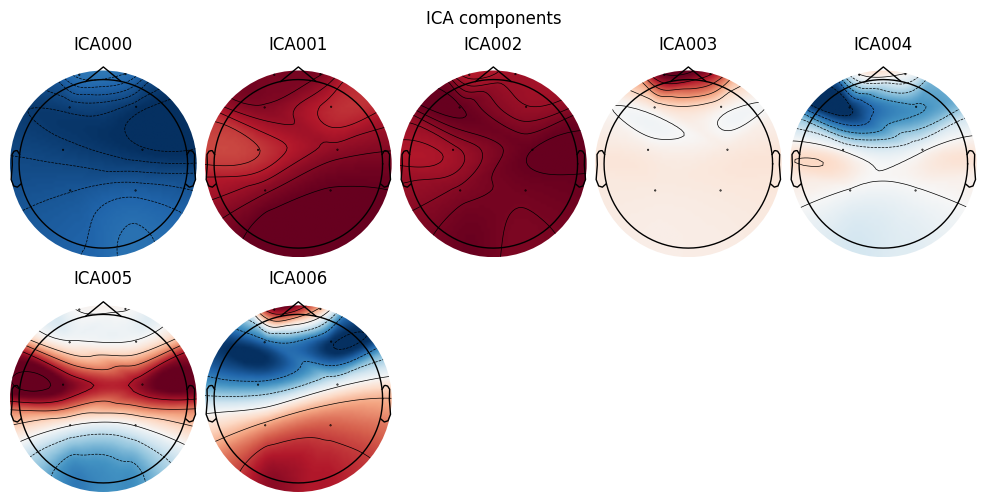

Creating RawArray with float64 data, n_channels=7, n_times=2500
    Range : 0 ... 2499 =      0.000 ...     9.996 secs
Ready.


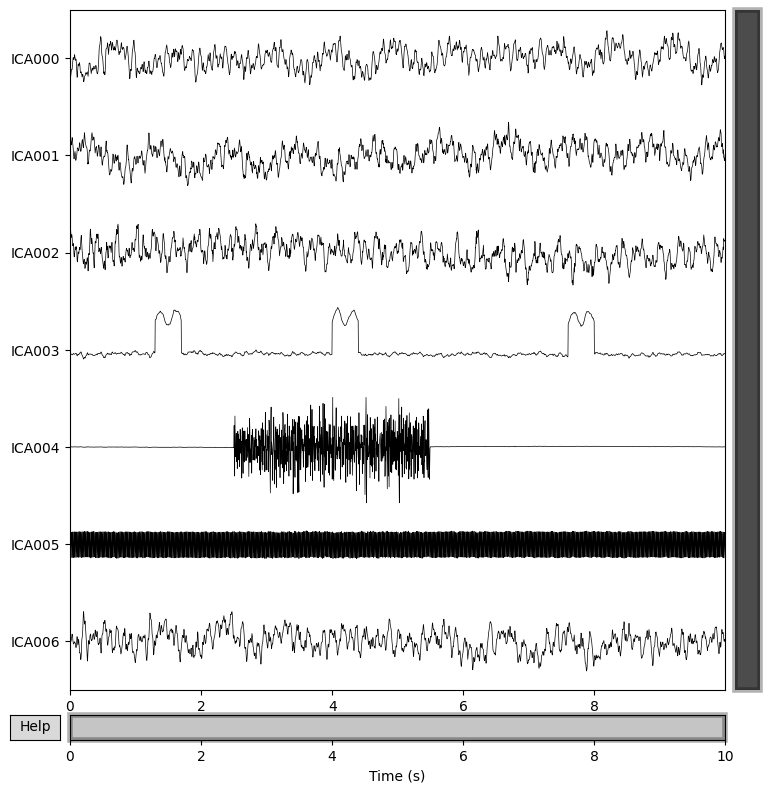


После ICA:
SNR: до очистки = 3.76 дБ, после = 0.02 дБ
Корреляция с оригиналом: до = 0.865, после = 0.067


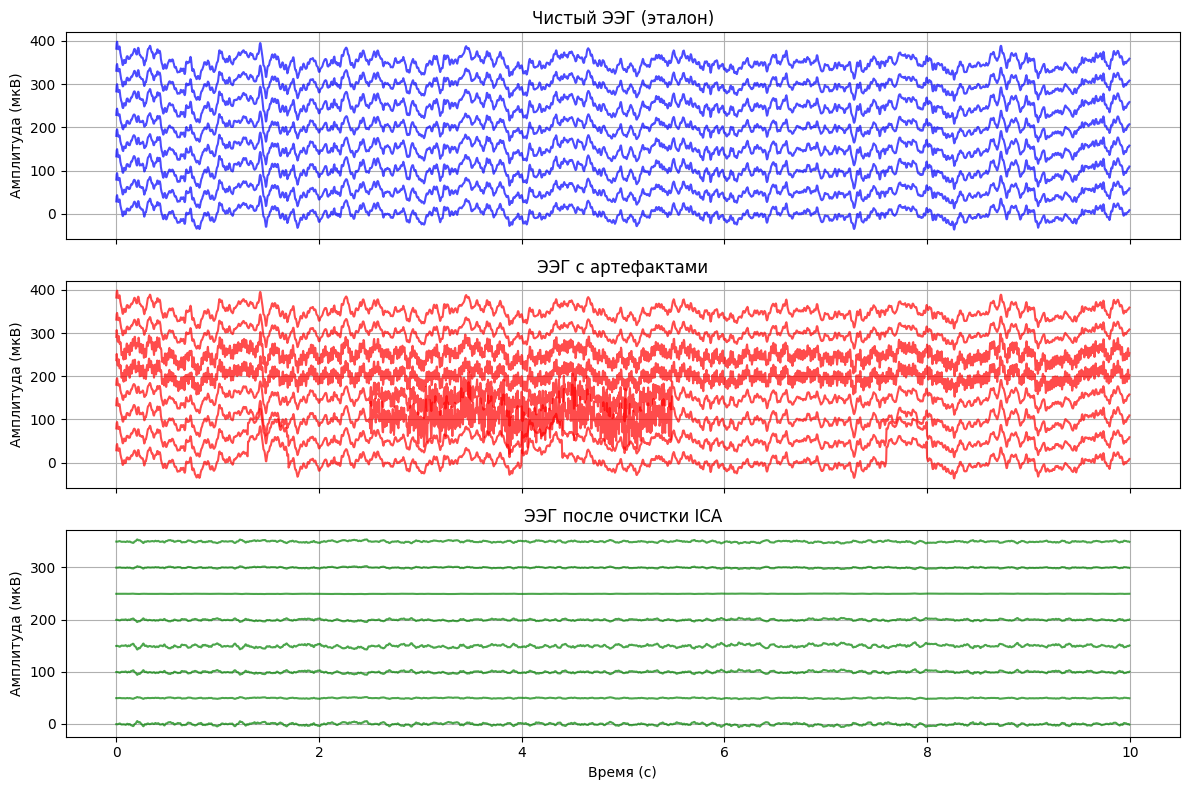

In [15]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt

# 1. ЗАДАНИЕ ФИКСИРОВАННОГО ЗНАЧЕНИЯ ДЛЯ ВОСПРОИЗВОДИМОСТИ
# Определение константы SEED для воспроизводимости результатов
# Это критически важно для научных экспериментов и отладки
SEED = 42

# 2. ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ
# Генерация чистого ЭЭГ-сигнала с помощью ранее определенной функции generate_eeg
# Параметры:
# - sfreq=250: частота дискретизации 250 Гц (стандартное значение для ЭЭГ)
# - n_channels=8: количество каналов (электродов)
# - seed=SEED: установка зерна для генератора случайных чисел
# Возвращаемые значения:
# - times: массив временных меток
# - eeg_clean: матрица чистого ЭЭГ-сигнала [каналы, отсчеты]
# - _: информация об источниках (не используется в данном контексте)
times, eeg_clean, _ = generate_eeg(sfreq=250, n_channels=8, seed=SEED)

# Добавление реалистичных артефактов к чистому сигналу
# Используется функция add_artifacts с тем же зерном случайных чисел для воспроизводимости
# Артефакты включают:
# - Моргания (blinks) с характерной формой и локализацией в лобных каналах
# - Мышечные артефакты с высокочастотным содержанием
# - Сетевую помеху 50 Гц с возможными гармониками
eeg_noisy = add_artifacts(times, eeg_clean, sfreq=250, seed=SEED)

# 3. БАЗОВАЯ ОЦЕНКА КАЧЕСТВА ДО ОЧИСТКИ
# Вывод заголовка для разделения этапов обработки
print("До ICA:")
# Вызов функции оценки качества с передачей:
# - eeg_clean: эталонный чистый сигнал
# - eeg_noisy: загрязненный сигнал
# - eeg_noisy: третий параметр также загрязненный сигнал (базовый уровень для сравнения)
# Эта оценка покажет начальное качество сигнала с артефактами
evaluate_ica(eeg_clean, eeg_noisy, eeg_noisy)  # Базовый уровень

# 4. ПРИМЕНЕНИЕ МЕТОДА НЕЗАВИСИМЫХ КОМПОНЕНТ (ICA) ДЛЯ ОЧИСТКИ
# Вызов функции apply_ica_to_eeg с детальной настройкой параметров:
# - eeg_noisy: исходные загрязненные данные
# - sfreq=250: частота дискретизации
# - n_components=7: количество независимых компонент для анализа
#   (на 1 меньше количества каналов, что является стандартной практикой)
# - method='picard': выбор современного и точного алгоритма ICA
# - verbose=True: вывод подробной информации о процессе обработки
# - visualize=True: включение визуализации компонентов для ручной проверки
#   (критически важно для верификации автоматической детекции артефактов)
# Возвращаемые значения:
# - eeg_ica: очищенные данные ЭЭГ
# - ica_obj: объект ICA с полной информацией о компонентах
# - excluded: список индексов компонентов, автоматически классифицированных как артефакты
eeg_ica, ica_obj, excluded = apply_ica_to_eeg(
    eeg_noisy,
    sfreq=250,
    n_components=7,          # Явное указание количества компонентов
    method='picard',         # Оптимальный метод для биомедицинских сигналов
    verbose=True,
    visualize=True           # Обязательная визуальная проверка компонентов
)

# 5. ФИНАЛЬНАЯ ОЦЕНКА КАЧЕСТВА ПОСЛЕ ОЧИСТКИ
# Вывод заголовка для разделения этапов обработки
print("\nПосле ICA:")
# Повторный вызов функции оценки с передачей очищенного сигнала
# Сравнение результатов до и после очистки покажет эффективность метода
# Параметры:
# - eeg_clean: эталонный чистый сигнал
# - eeg_noisy: исходный загрязненный сигнал
# - eeg_ica: очищенный сигнал после применения ICA
evaluate_ica(eeg_clean, eeg_noisy, eeg_ica)

# 6. ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (РЕКОМЕНДУЕТСЯ ДОБАВИТЬ)
# Для полного анализа рекомендуется добавить визуальное сравнение сигналов:

# Создание фигуры для визуализации
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Визуализация чистого сигнала
for i in range(eeg_clean.shape[0]):
    axes[0].plot(times, eeg_clean[i] + i*50, 'b', alpha=0.7)  # Смещение для лучшей видимости
axes[0].set_title('Чистый ЭЭГ (эталон)')
axes[0].set_ylabel('Амплитуда (мкВ)')
axes[0].grid(True)

# Визуализация загрязненного сигнала
for i in range(eeg_noisy.shape[0]):
    axes[1].plot(times, eeg_noisy[i] + i*50, 'r', alpha=0.7)
axes[1].set_title('ЭЭГ с артефактами')
axes[1].set_ylabel('Амплитуда (мкВ)')
axes[1].grid(True)

# Визуализация очищенного сигнала
for i in range(eeg_ica.shape[0]):
    axes[2].plot(times, eeg_ica[i] + i*50, 'g', alpha=0.7)
axes[2].set_title('ЭЭГ после очистки ICA')
axes[2].set_xlabel('Время (с)')
axes[2].set_ylabel('Амплитуда (мкВ)')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('ica_comparison.png', dpi=300)
plt.show()